<a href="https://colab.research.google.com/github/Anushka-Pokhriyal/Gravitational-Wave-Signal-Classification/blob/main/Gravitational_Wave_Signal_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/archive (1).zip" -d /content/dataset


Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/train/train/Whistle/L1_jbSGPY9SuI_spectrogram_1.0.png  
  inflating: /content/dataset/train/train/Whistle/L1_jbSGPY9SuI_spectrogram_2.0.png  
  inflating: /content/dataset/train/train/Whistle/L1_jbSGPY9SuI_spectrogram_4.0.png  
  inflating: /content/dataset/train/train/Whistle/L1_jbxYeVDEAK_spectrogram_0.5.png  
  inflating: /content/dataset/train/train/Whistle/L1_jbxYeVDEAK_spectrogram_1.0.png  
  inflating: /content/dataset/train/train/Whistle/L1_jbxYeVDEAK_spectrogram_2.0.png  
  inflating: /content/dataset/train/train/Whistle/L1_jbxYeVDEAK_spectrogram_4.0.png  
  inflating: /content/dataset/train/train/Whistle/L1_jsK4vgBbeO_spectrogram_0.5.png  
  inflating: /content/dataset/train/train/Whistle/L1_jsK4vgBbeO_spectrogram_1.0.png  
  inflating: /content/dataset/train/train/Whistle/L1_jsK4vgBbeO_spectrogram_2.0.png  
  inflating: /content/dataset/train/train/Whistle/L1_jsK4vgBbeO_spectrogram_4.0.png  
  i

In [ ]:
!unzip -q "/content/archive (1).zip" -d /content/dataset

unzip:  cannot find or open /content/archive (1).zip, /content/archive (1).zip.zip or /content/archive (1).zip.ZIP.


In [ ]:
!ls /content

dataset  drive	sample_data


In [ ]:
!ls /content/dataset

test  train  trainingset_v1d1_metadata.csv  validation


In [ ]:
!ls /content/dataset/train

train


In [ ]:
train_path = "/content/dataset/train"

In [ ]:
train_path = "/content/dataset/train/train"
val_path   = "/content/dataset/validation/validation"
test_path  = "/content/dataset/test/test"

In [ ]:
!ls /content/dataset/train/train

1080Lines	Helix		     None_of_the_Above	Tomte
1400Ripples	Koi_Fish	     Paired_Doves	Violin_Mode
Air_Compressor	Light_Modulation     Power_Line		Wandering_Line
Blip		Low_Frequency_Burst  Repeating_Blips	Whistle
Chirp		Low_Frequency_Lines  Scattered_Light
Extremely_Loud	No_Glitch	     Scratchy


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/content/dataset/train/train",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    "/content/dataset/validation/validation",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    "/content/dataset/test/test",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 22348 images belonging to 22 classes.
Found 4800 images belonging to 22 classes.
Found 4720 images belonging to 22 classes.


In [ ]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),   # prevents overfitting
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
699/699 ━━━━━━━━━━━━━━━━━━━━ 1165s 2s/step - accuracy: 0.7810 - loss: 0.7843 - val_accuracy: 0.9242 - val_loss: 0.2643
Epoch 2/10
699/699 ━━━━━━━━━━━━━━━━━━━━ 1127s 2s/step - accuracy: 0.9023 - loss: 0.3334 - val_accuracy: 0.9267 - val_loss: 0.2488
Epoch 3/10
699/699 ━━━━━━━━━━━━━━━━━━━━ 1035s 1s/step - accuracy: 0.9196 - loss: 0.2705 - val_accuracy: 0.9367 - val_loss: 0.2131
Epoch 4/10
699/699 ━━━━━━━━━━━━━━━━━━━━ 1103s 2s/step - accuracy: 0.9339 - loss: 0.2118 - val_accuracy: 0.9473 - val_loss: 0.1981
Epoch 5/10
699/699 ━━━━━━━━━━━━━━━━━━━━ 1146s 2s/step - accuracy: 0.9451 - loss: 0.1863 - val_accuracy: 0.9417 - val_loss: 0.2006
Epoch 6/10
699/699 ━━━━━━━━━━━━━━━━━━━━ 1070s 2s/step - accuracy: 0.9511 - loss: 0.1597 - val_accuracy: 0.9431 - val_loss: 0.2079
Epoch 7/10
699/699 ━━━━━━━━━━━━━━━━━━━━ 1061s 2s/step - accuracy: 0.9569 - loss: 0.1437 - val_accuracy: 0.9435 - val_loss: 0.2262
Epoch 8/10
699/699 ━━━━━━━━━━━━━━━━━━━━ 1105s 2s/step - accuracy: 0.9639 - loss: 0.1198 - 

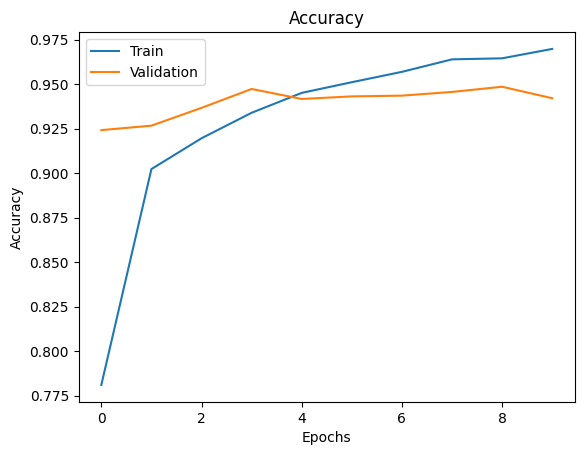

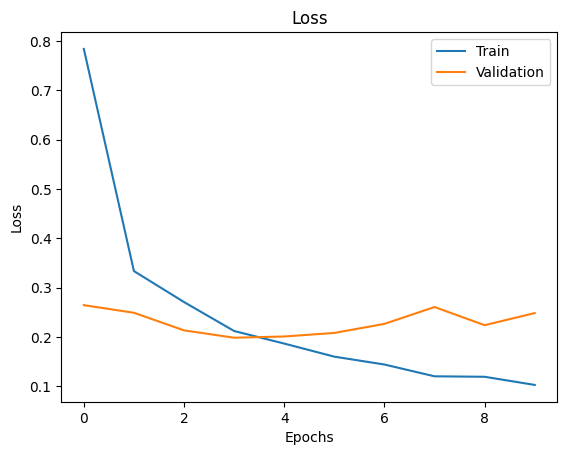

In [16]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

In [17]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

148/148 ━━━━━━━━━━━━━━━━━━━━ 105s 703ms/step - accuracy: 0.9475 - loss: 0.2969
Test Accuracy: 0.9474576115608215


148/148 ━━━━━━━━━━━━━━━━━━━━ 116s 777ms/step


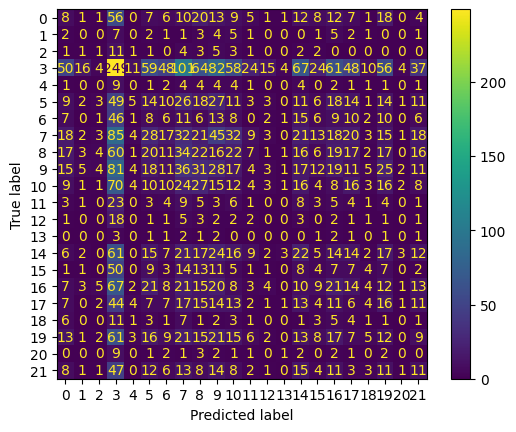

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step


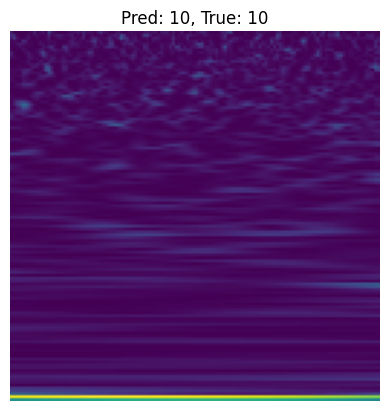

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


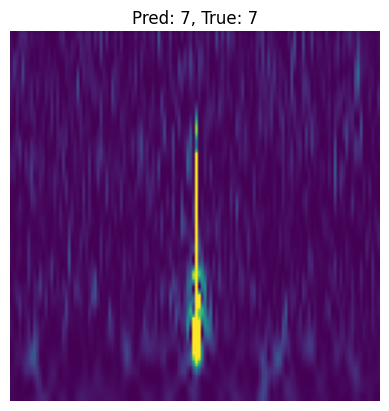

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


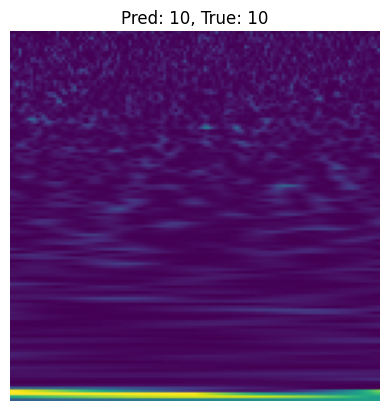

In [19]:
images, labels = next(test_data)

for i in range(3):
    plt.imshow(images[i])
    pred = np.argmax(model.predict(images[i].reshape(1,128,128,3)))
    true = np.argmax(labels[i])

    plt.title(f"Pred: {pred}, True: {true}")
    plt.axis('off')
    plt.show()

In [20]:
model.save("gravity_wave_model.h5")

In [21]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [22]:
from tensorflow.keras.applications import ResNet50

In [24]:
y_pred = model.predict(test_data)
y_true = test_data.classes

148/148 ━━━━━━━━━━━━━━━━━━━━ 91s 612ms/step


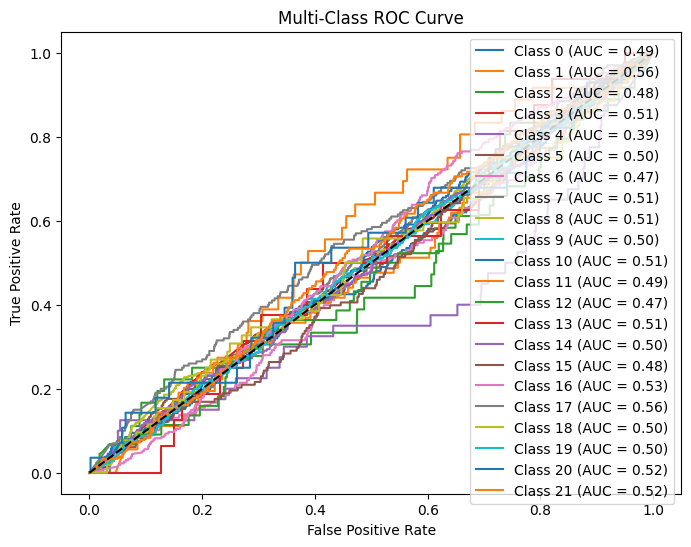

In [25]:
# === MULTI-CLASS ROC CURVE ADD-ON ===

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Convert true labels to one-hot
y_true_bin = label_binarize(y_true, classes=range(train_data.num_classes))

# Plot ROC curve for each class
plt.figure(figsize=(8,6))

for i in range(train_data.num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

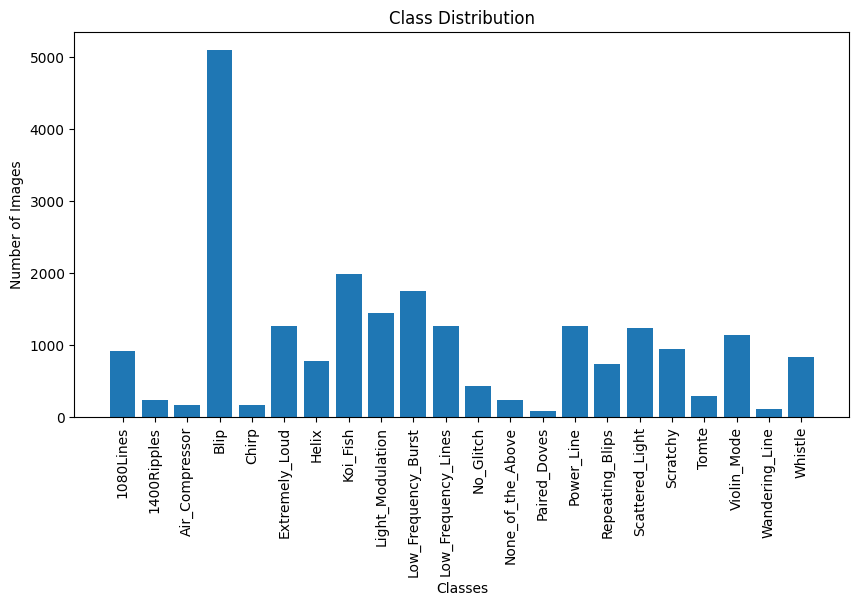

In [27]:
import os
import matplotlib.pyplot as plt

class_names = list(train_data.class_indices.keys())
counts = [len(os.listdir(f"/content/dataset/train/train/{cls}")) for cls in class_names]

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

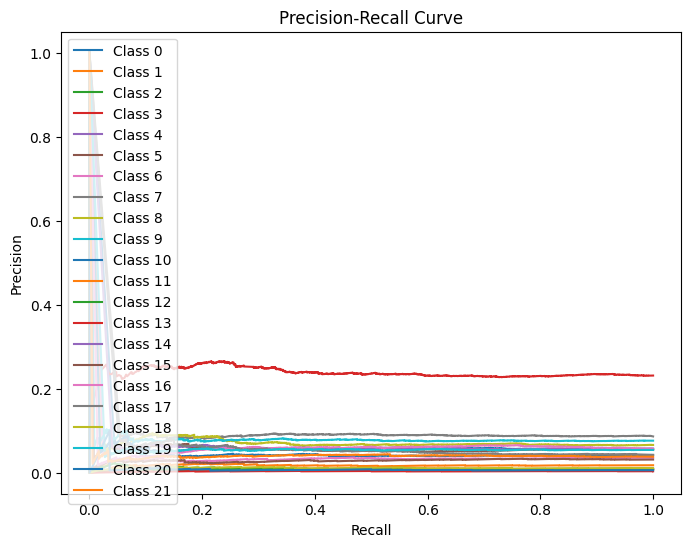

In [28]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(train_data.num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


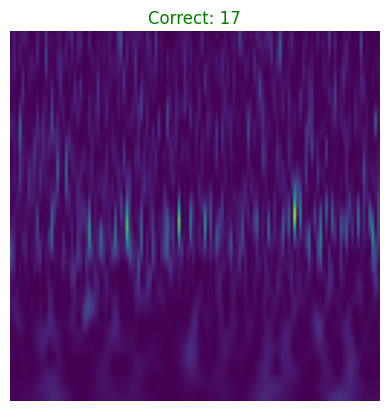

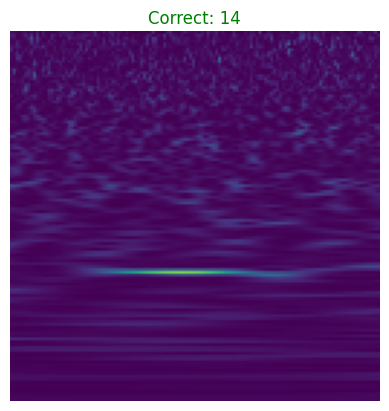

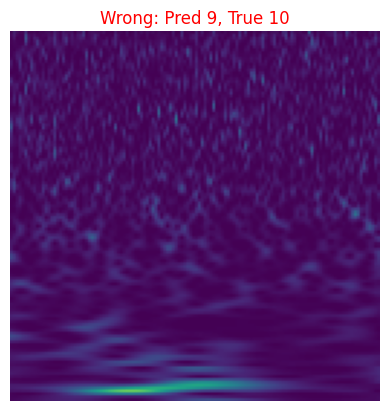

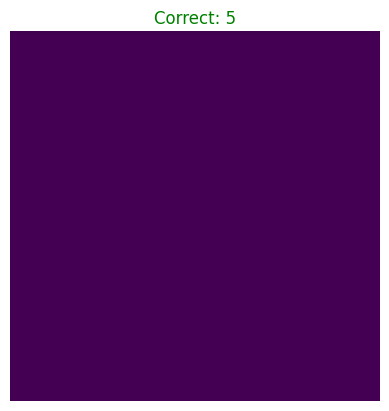

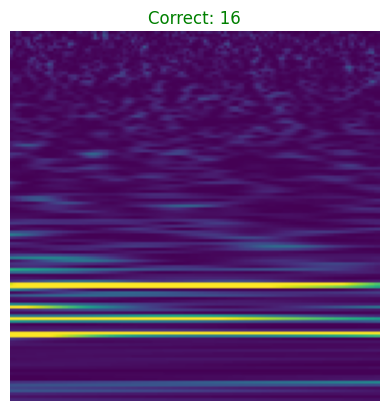

In [30]:
#correct vs wrong impressions
import numpy as np

images, labels = next(test_data)
preds = model.predict(images)

for i in range(5):
    plt.imshow(images[i])
    pred = np.argmax(preds[i])
    true = np.argmax(labels[i])

    if pred == true:
        plt.title(f"Correct: {pred}", color='green')
    else:
        plt.title(f"Wrong: Pred {pred}, True {true}", color='red')

    plt.axis('off')
    plt.show()

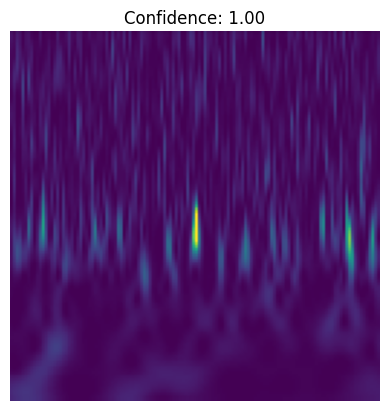

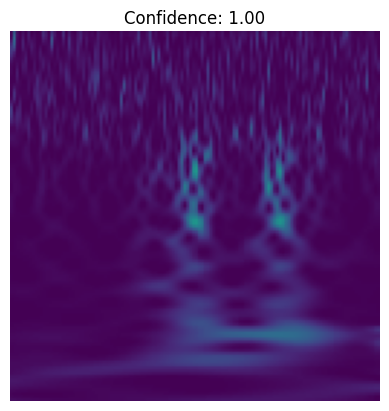

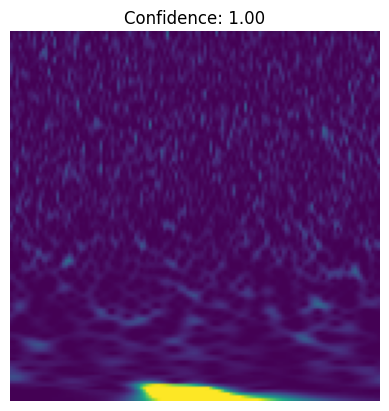

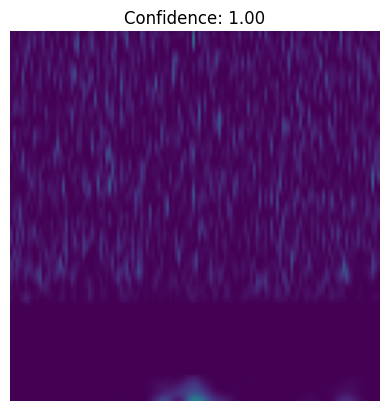

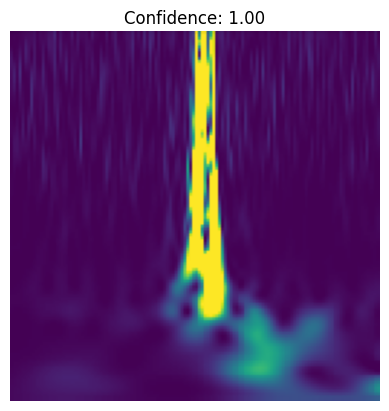

In [33]:
#top confident predictions
confidence = np.max(y_pred, axis=1)

top_idx = np.argsort(confidence)[-5:]

for i in top_idx:
    img, _ = next(test_data)
    plt.imshow(img[0])
    plt.title(f"Confidence: {confidence[i]:.2f}")
    plt.axis('off')
    plt.show()


148/148 ━━━━━━━━━━━━━━━━━━━━ 98s 653ms/step


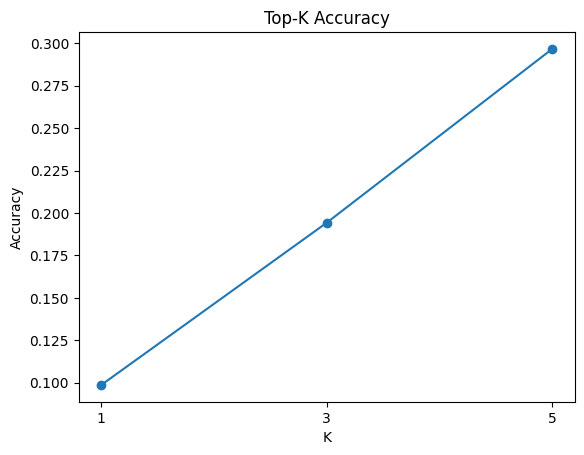

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# True labels
y_true = test_data.classes

# Predictions
y_pred = model.predict(test_data)

# Calculate Top-K accuracy
top_k = [1, 3, 5]
accuracies = []

for k in top_k:
    correct = 0
    for i in range(len(y_true)):
        top_k_preds = np.argsort(y_pred[i])[-k:]
        if y_true[i] in top_k_preds:
            correct += 1
    accuracies.append(correct / len(y_true))

# Plot
plt.plot(top_k, accuracies, marker='o')
plt.title("Top-K Accuracy")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(top_k)
plt.show()